In [ ]:
Introduction

Sales demand forecasting is the process of predicting future sales based on historical sales data. It helps businesses understand sales trends, plan inventory, manage resources, and make better decisions.

In this project, historical Superstore sales data is analyzed to identify sales patterns and trends. Time-based features such as Year, Month, and Quarter are used to build a machine learning model for predicting future sales demand.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Task 1 setup ready!")

Task 1 setup ready!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv.zip to Sample - Superstore.csv.zip


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (8469, 20)

Columns:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'ticket_text', 'clean_ticket', 'model_text']

Missing Values:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution    

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,ticket_text,clean_ticket,model_text
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,Product setup I'm having an issue with the {pr...,product setup issue product purchased please a...,Product setup I'm having an issue with the {pr...
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,Peripheral compatibility I'm having an issue w...,peripheral compatibility issue product purchas...,Peripheral compatibility I'm having an issue w...
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,Network problem I'm facing a problem with my {...,network problem facing problem product purchas...,Network problem I'm facing a problem with my {...
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,Account access I'm having an issue with the {p...,account access issue product purchased please ...,Account access I'm having an issue with the {p...
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,Data loss I'm having an issue with the {produc...,data loss issue product purchased please assis...,Data loss I'm having an issue with the {produc...


In [ ]:
import pandas as pd

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv.zip to Sample - Superstore.csv.zip


In [ ]:
import pandas as pd
import zipfile
import os

zip_path = '/content/Sample - Superstore.csv.zip'

# Extract ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/superstore_data')

# Check extracted files
print(os.listdir('/content/superstore_data'))

['Sample - Superstore.csv']


In [ ]:
import pandas as pd

df = pd.read_csv(
    '/content/superstore_data/Sample - Superstore.csv',
    encoding='latin1'
)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Check date range
print("Start Date:", df['Order Date'].min())
print("End Date:", df['Order Date'].max())

# Check missing dates
print("Missing Dates:", df['Order Date'].isnull().sum())

Start Date: 2014-01-03 00:00:00
End Date: 2017-12-30 00:00:00
Missing Dates: 0


In [ ]:
# Create monthly sales data
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum().reset_index()

# Convert month back to datetime
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

# Rename columns
monthly_sales.columns = ['Date', 'Sales']

# Display the data
print("Monthly Sales Shape:", monthly_sales.shape)
display(monthly_sales.head(10))

Monthly Sales Shape: (48, 2)


,Date,Sales
0,2014-01-01,14236.8950
1,2014-02-01,4519.8920
2,2014-03-01,55691.0090
3,2014-04-01,28295.3450
4,2014-05-01,23648.2870
5,2014-06-01,34595.1276
6,2014-07-01,33946.3930
7,2014-08-01,27909.4685
8,2014-09-01,81777.3508
9,2014-10-01,31453.3930


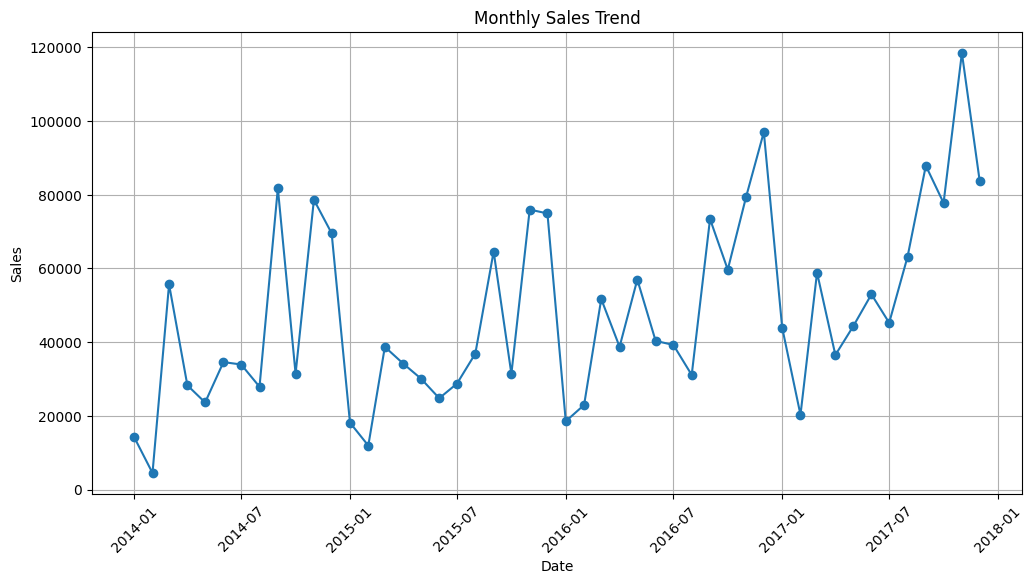

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales['Date'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# Create time-based features
monthly_sales['Year'] = monthly_sales['Date'].dt.year
monthly_sales['Month'] = monthly_sales['Date'].dt.month
monthly_sales['Quarter'] = monthly_sales['Date'].dt.quarter

# Display the updated data
display(monthly_sales.head(12))

,Date,Sales,Year,Month,Quarter
0,2014-01-01,14236.8950,2014,1,1
1,2014-02-01,4519.8920,2014,2,1
2,2014-03-01,55691.0090,2014,3,1
3,2014-04-01,28295.3450,2014,4,2
4,2014-05-01,23648.2870,2014,5,2
5,2014-06-01,34595.1276,2014,6,2
6,2014-07-01,33946.3930,2014,7,3
7,2014-08-01,27909.4685,2014,8,3
8,2014-09-01,81777.3508,2014,9,3
9,2014-10-01,31453.3930,2014,10,4


In [ ]:
# Split data into training and testing sets
train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales.iloc[:train_size].copy()
test = monthly_sales.iloc[train_size:].copy()

print("Training Data:", train.shape)
print("Testing Data:", test.shape)

print("\nTraining Period:")
print(train['Date'].min(), "to", train['Date'].max())

print("\nTesting Period:")
print(test['Date'].min(), "to", test['Date'].max())

Training Data: (38, 5)
Testing Data: (10, 5)

Training Period:
2014-01-01 00:00:00 to 2017-02-01 00:00:00

Testing Period:
2017-03-01 00:00:00 to 2017-12-01 00:00:00


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Features and target
features = ['Year', 'Month', 'Quarter']

X_train = train[features]
y_train = train['Sales']

X_test = test[features]
y_test = test['Sales']

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Mean Absolute Error (MAE): 10602.95
Root Mean Squared Error (RMSE): 16094.19


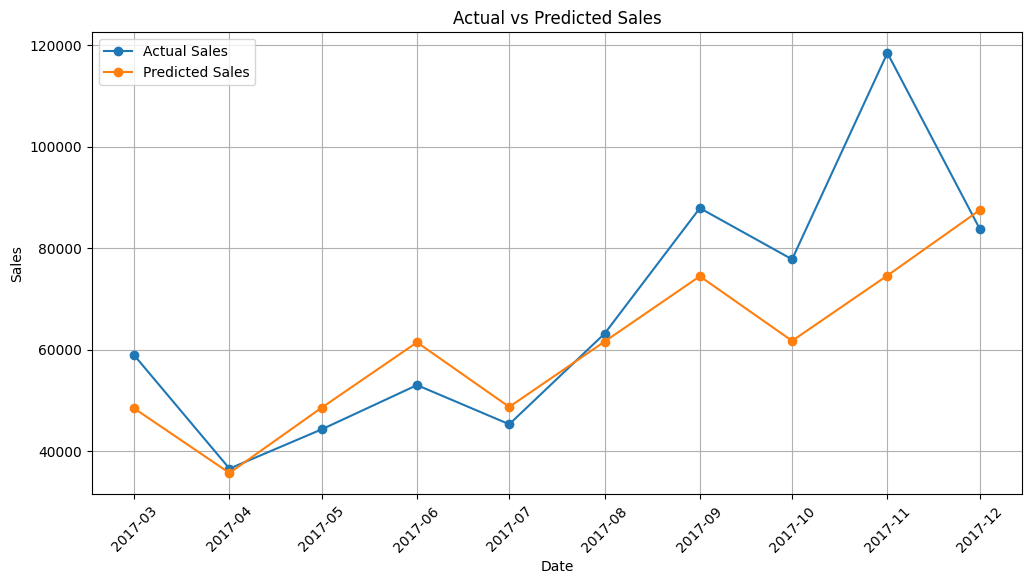

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    test['Date'],
    y_test,
    marker='o',
    label='Actual Sales'
)

plt.plot(
    test['Date'],
    y_pred,
    marker='o',
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# Create future dates for the next 6 months
future_dates = pd.date_range(
    start='2018-01-01',
    periods=6,
    freq='MS'
)

future = pd.DataFrame({
    'Date': future_dates
})

# Create time-based features
future['Year'] = future['Date'].dt.year
future['Month'] = future['Date'].dt.month
future['Quarter'] = future['Date'].dt.quarter

# Predict future sales
future['Predicted Sales'] = model.predict(
    future[['Year', 'Month', 'Quarter']]
)

# Display forecast
display(future)

,Date,Year,Month,Quarter,Predicted Sales
0,2018-01-01,2018,1,1,28352.862152
1,2018-02-01,2018,2,1,41230.714715
2,2018-03-01,2018,3,1,54108.567278
3,2018-04-01,2018,4,2,41375.391619
4,2018-05-01,2018,5,2,54253.244182
5,2018-06-01,2018,6,2,67131.096744


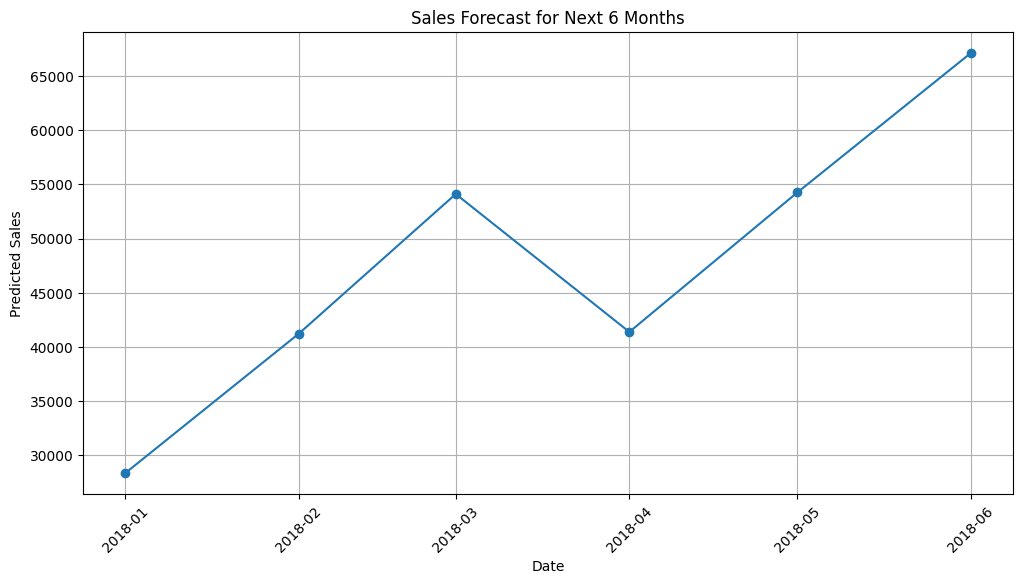

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    future['Date'],
    future['Predicted Sales'],
    marker='o'
)

plt.title('Sales Forecast for Next 6 Months')
plt.xlabel('Date')
plt.ylabel('Predicted Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
## Conclusion

The Sales Demand Forecasting system was developed using historical Superstore sales data.

The dataset contained 9,994 records covering the period from 2014 to 2017. Monthly sales data was created and time-based features such as Year, Month, and Quarter were used for forecasting.

A Linear Regression model was trained using 80% of the data and evaluated on the remaining 20%.

Model Performance:
- Mean Absolute Error (MAE): 10,602.95
- Root Mean Squared Error (RMSE): 16,094.19

The model was also used to forecast sales for the next six months. The highest predicted sales was approximately 67,131 in June 2018.

This project demonstrates how machine learning and time-based features can be used to analyze sales trends and support future demand forecasting.